In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [13]:
# Upload the CSV file
df =pd.read_csv('data.csv', encoding='windows-1254')
df.shape

(541909, 8)

In [14]:
#Print first five index
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [15]:
# Print the info of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [16]:
# Print the description of the data of the numbers
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [17]:
pd.isnull(df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
541904,False,False,False,False,False,False,False,False
541905,False,False,False,False,False,False,False,False
541906,False,False,False,False,False,False,False,False
541907,False,False,False,False,False,False,False,False


In [18]:
# Print the sum (count) of the null value 
pd.isnull(df).sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [19]:
# Fillna - Use this function to replace the null values as No Description Available
df['Description']= df['Description'].fillna('No Description Available')

In [20]:
# # Fillna - Use this function to replace the null values as zero.
df['CustomerID']= df['CustomerID'].fillna(0)

In [21]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [22]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [23]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [24]:
# Creating new column
df['Total_amount'] = df['Quantity'] * df['UnitPrice']

In [25]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


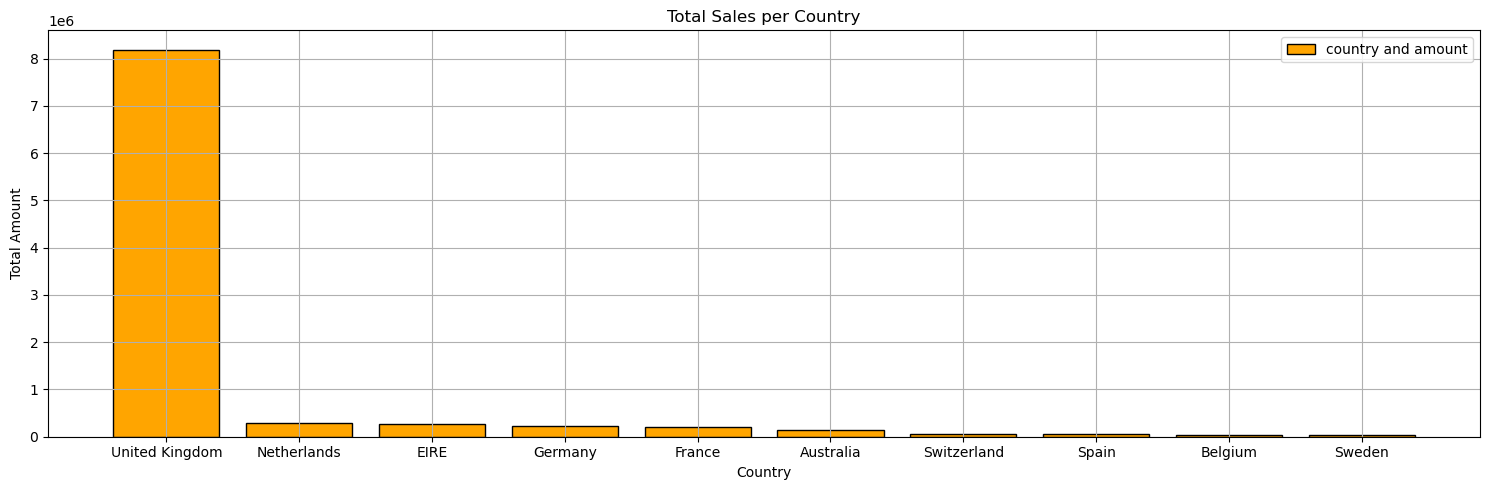

In [26]:
# matplot of Country and Total Amount (bar chart)
country_sales = df.groupby('Country')['Total_amount'].sum().sort_values(ascending=False)
countries = country_sales.index[:10]
sales = country_sales.values[:10]

plt.figure (figsize=(15,5))
plt.bar(countries,sales, color='orange',edgecolor='black',linestyle ='-',label= "country and amount")
plt.title("Total Sales per Country")
plt.xlabel('Country')
plt.ylabel('Total Amount')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()     

In [27]:
df['Month']= df['InvoiceDate'].dt.to_period("M")
monthly_sales= df.groupby('Month')['Total_amount'].sum()


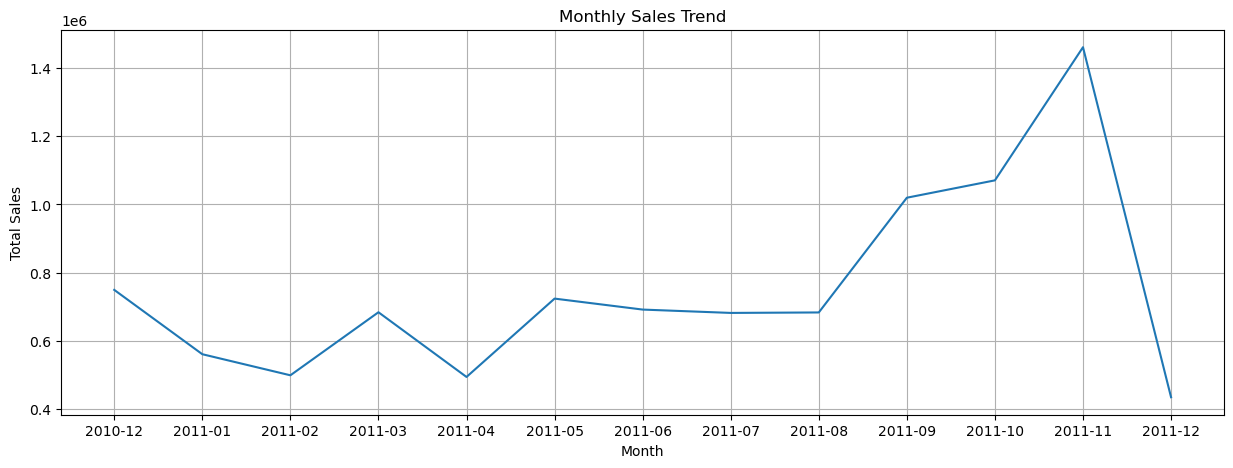

In [28]:
# Prepare data
x = monthly_sales.index.astype(str)  
y = monthly_sales.values             

# Simple plot
plt.figure(figsize=(15,5))
plt.plot(x, y) 
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [29]:
df['Quantity'].dtype

dtype('int64')

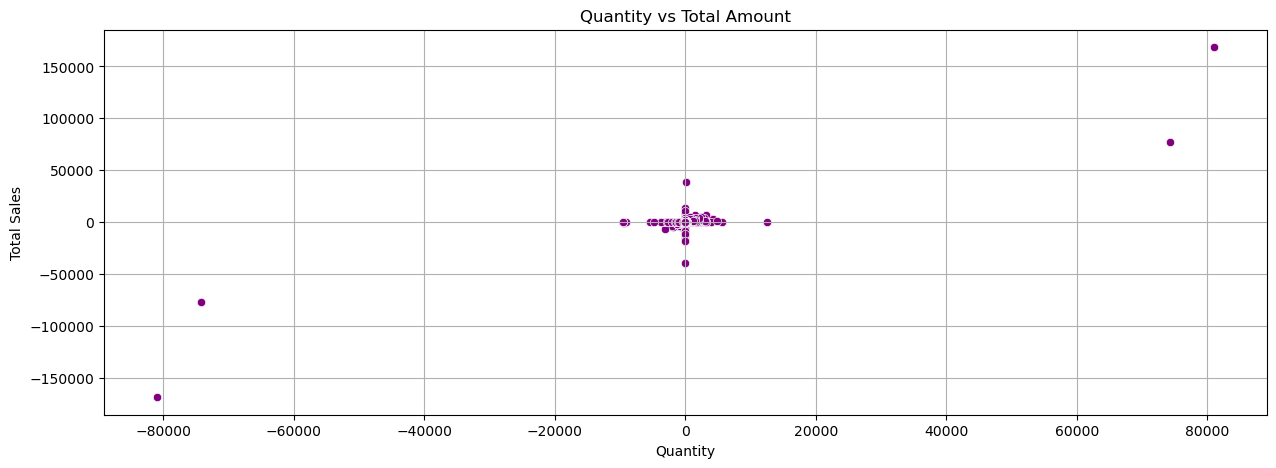

In [30]:
# Scatter Plot
plt.figure(figsize=(15,5))
sns.scatterplot(x='Quantity', y='Total_amount',data=df,color='purple') 
plt.title('Quantity vs Total Amount')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

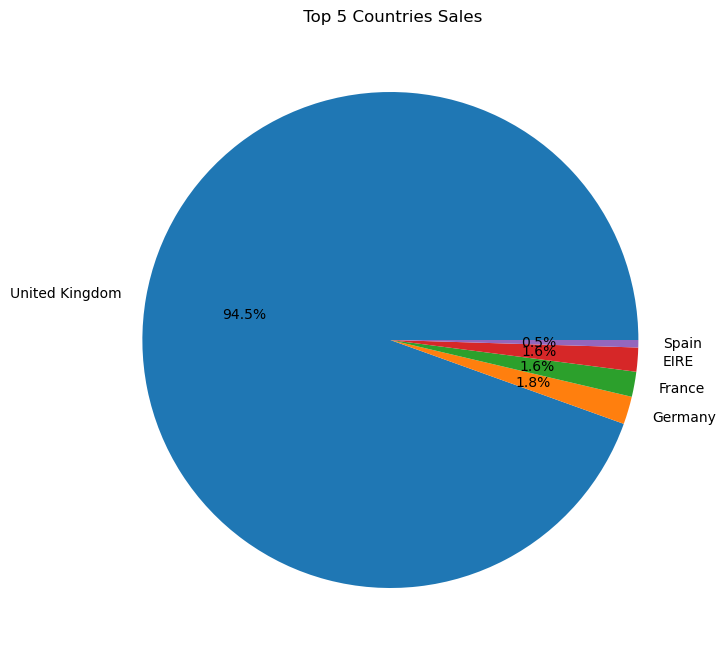

In [31]:
# Pie Chart
plt.figure(figsize=(8,10))
plt.pie(df['Country'].value_counts().head(5),labels=df['Country'].value_counts().head(5).index,autopct='%1.1f%%')
plt.title(' Top 5 Countries Sales')
plt.show()

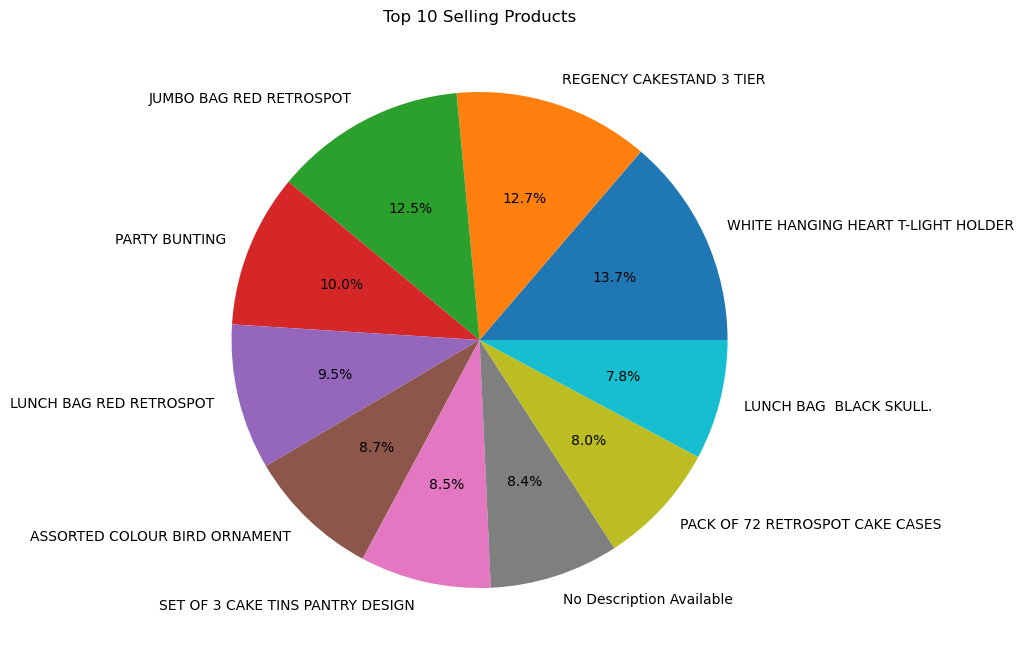

In [32]:
plt.figure(figsize=(8,10))
plt.pie(df['Description'].value_counts().head(10),labels=df['Description'].value_counts().head(10).index,autopct='%1.1f%%')
plt.title('Top 10 Selling Products')
plt.show()

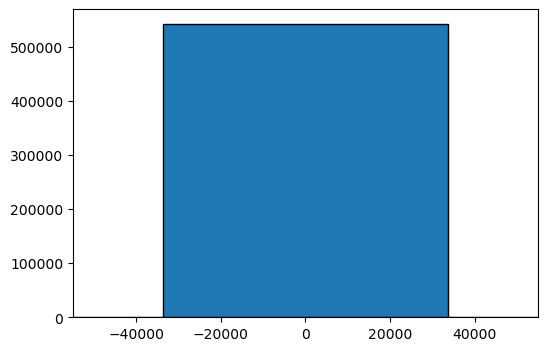

In [33]:
# Histogram Chart
plt.figure(figsize=(6,4))
plt.hist(df['Total_amount'], bins=5, edgecolor='black')
plt.xlabel=('Total_amount')
plt.ylabel=('Frequency')
plt.title=('')
plt.xlim(-55000,55000)
plt.show()

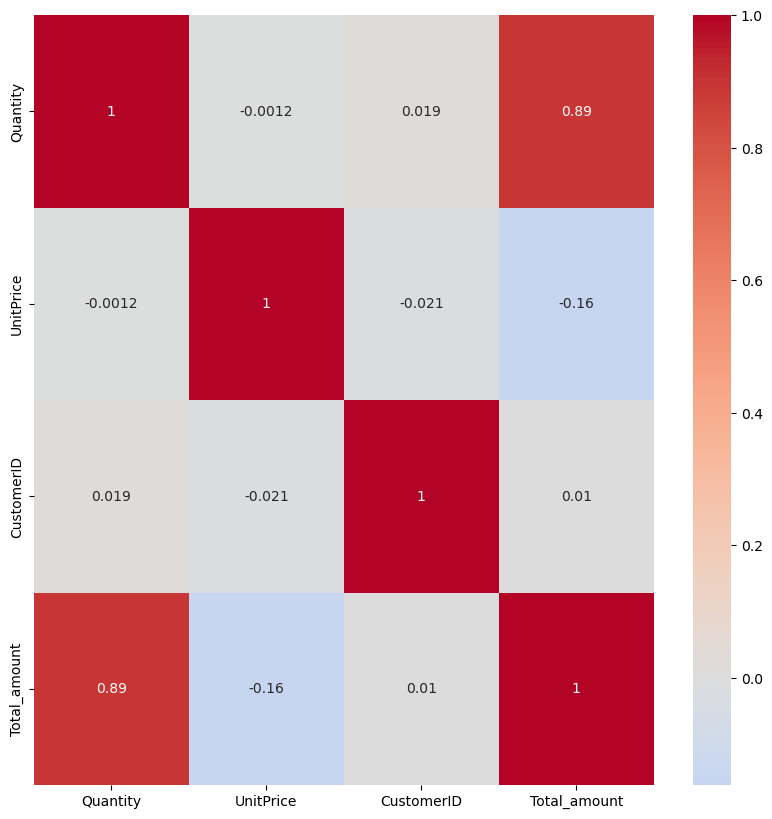

In [34]:
# Create correlation heatmap
plt.figure(figsize=(10, 10))
data= df.select_dtypes(include=['int64','float64'])
corr =data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show() 

In [35]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree

x= df[['Quantity','UnitPrice']]
y= df[['Total_amount']]

x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=10)

lr= LinearRegression()
lr.fit(x_train,y_train)

y_pred_lr= lr.predict(x_test)

mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Model Performance Metrics:")
print("Mean Square Error:", mse)
print("Root-Mean Square Error:", rmse)
print("R-squared Score:", r2)

Model Performance Metrics:
Mean Square Error: 41338.09655424226
Root-Mean Square Error: 203.317723168056
R-squared Score: 0.8507050230206354


In [38]:
# Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

features =['Quantity','UnitPrice']
x= df[features]
y= df[['Total_amount']]

dt_model= DecisionTreeRegressor()
dt_model.fit(x_train,y_train)

y_pred_dt= dt_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print("Model Performance Metrics:")
print("Mean Square Error:", mse)
print("Root-Mean Square Error:", rmse)
print("R-squared Score:", r2)

Model Performance Metrics:
Mean Square Error: 9.226624347216328e-06
Root-Mean Square Error: 0.003037535900564194
R-squared Score: 0.9999467970954363


In [37]:
# Logistic Regression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create a flag: High Sale = 1 , Low Sale = 0
df["SaleFlag"] = np.where(df["Total_amount"] > df["Total_amount"].mean(), 1, 0)

X = df[['Quantity', 'UnitPrice']]
y = df['SaleFlag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

ac= accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:",ac)

Logistic Regression Accuracy: 0.8085014116735251
